# Deep Learning with Python - 3th ed.
Francois Chollet
Matthew Watson


<img src="../pics/cover_DeepLearning.jpg" width=400> 

https://github.com/fchollet/deep-learning-with-python-notebooks

https://github.com/cr2003/BK_DeepLearning_with_Python_3ed



<a href="file:///C:/Users/crodr/OneDrive/InterChange/Books/Tech/DeepLearnig/Deep Learning with Python, Third Edition (François Chollet, Matthew Watson) (z-library.sk, 1lib.sk, z-lib.sk).pdf" target="_blank">Abrir PDF Local</a>

In [3]:
import os

# Definimos la ruta de tu libro
ruta_libro = r"C:\Users\crodr\OneDrive\InterChange\Books\Tech\DeepLearnig\Deep Learning with Python, Third Edition (François Chollet, Matthew Watson) (z-library.sk, 1lib.sk, z-lib.sk).pdf"

# Esto le dice a Windows: "Abre este archivo con el programa por defecto del sistema"
os.startfile(ruta_libro)

In [1]:
!pwd

/c/Users/crodr/BK_tech/DeepLearning/BK_DeepLearning_with_Python_3ed/ch03


In [2]:
!python --version

Python 3.12.10


# Chapter 03 - Introduction to TensorFlow, PyTorch, JAX, and Keras
## 3.3 Introduction to TensorFlow
### 3.3.1 First steps with TensorFlow
page 64

#### Tensors and Variables in TensorFlow
To do anything in TensorFlow, we’re going to need some tensors. There are a few different
ways you can create them.


##### Constant Tensors

Tensors need to be created with some initial value, so common ways to create tensors
are via` tf.ones` (equivalent to `np.ones`) and `tf.zeros` (equivalent to `np.zeros`). You can
also create a tensor from Python or NumPy values using `tf.constant`.

In [ ]:
import tensorflow as tf

tf.ones(shape=(2, 1))  # Equivalent to np.ones(shape=(2, 1))

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[1.],
       [1.]], dtype=float32)>

In [ ]:
tf.zeros(shape=(2, 1))  # Equivalent to np.zeros(shape=(2, 1))

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[0.],
       [0.]], dtype=float32)>

In [ ]:
tf.constant(
    [1, 2, 3], dtype="float32"
)  # Equivalent to np.array([1, 2, 3], dtype="float32")

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([1., 2., 3.], dtype=float32)>

##### Random Tensors

You can also create tensors filled with random values via one of the methods of the
`tf.random `submodule (equivalent to the `np.random` submodule).


In [ ]:
# Tensor of random values drawn from a normal distribution with mean 0 and standard deviation 1.
# Equivalent to np.random.normal(size=(3, 1), loc=0., scale=1.)
x = tf.random.normal(shape=(3, 1), mean=0.0, stddev=1.0)
print(x)

tf.Tensor(
[[ 0.3307532 ]
 [-0.3910844 ]
 [-0.42504266]], shape=(3, 1), dtype=float32)


In [ ]:
# Tensor of random values drawn from a uniform distribution between 0 and 1.
# Equivalent to np.random.uniform(size=(3, 1), low=0., high=1.)
x = tf.random.uniform(shape=(3, 1), minval=0.0, maxval=1.0)
print(x)

tf.Tensor(
[[0.8011745 ]
 [0.48506713]
 [0.66140115]], shape=(3, 1), dtype=float32)


#### Tensor assignment and the Variable Class
A significant difference between NumPy arrays and TensorFlow tensors is that Tensor-
Flow tensors aren’t assignable: they’re constant. For instance, in NumPy, you can do
the following.

In [8]:
import numpy as np

x = np.ones(shape=(2, 2))
x[0, 0] = 0.0
x

array([[0., 1.],
       [1., 1.]])

Try to do the same thing in TensorFlow: you will get an error, `EagerTensor object does
not support item assignment`.

In [ ]:
x = tf.ones(shape=(2, 2))
x[0, 0] = 0.0  # This will fail, as a tensor isn't assignable

TypeError: 'tensorflow.python.framework.ops.EagerTensor' object does not support item assignment

To train a model, we’ll need to update its state, which is a set of tensors. If tensors
aren’t assignable, how do we do it, then? That’s where variables come in. `tf.Variable` is
the class meant to manage modifiable state in TensorFlow.
To create a variable, you need to provide some initial value, such as a random tensor.

In [11]:
v = tf.Variable(initial_value=tf.random.normal(shape=(3, 1)))
print(v)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[ 0.66175324],
       [-0.657443  ],
       [ 0.9424959 ]], dtype=float32)>


The state of a variable can be modified via its `assign` method.

In [12]:
v.assign(tf.ones((3, 1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[1.],
       [1.],
       [1.]], dtype=float32)>

Assignment also works for a subset of the coefficients.

In [ ]:
v[0, 0].assign(3.0)

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[3.],
       [1.],
       [1.]], dtype=float32)>

Similarly, `assign_add` and `assign_sub` are efficient equivalents of `+=` and `-=`. 

In [15]:
v.assign_add(tf.ones((3, 1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[4.],
       [2.],
       [2.]], dtype=float32)>

#### Tensor Operations: Doing math in TensorFlow
Just like NumPy, TensorFlow offers a large collection of tensor operations to express
mathematical formulas. Here are a few examples.

In [ ]:
a = tf.ones((2, 2))
b = tf.square(a)  # takes the square, as as np.square
c = tf.sqrt(a)  # takes the square root, as as np.sqrt
d = b + c  # adds two tensors (element-wise)
e = tf.matmul(a, b)  # takes the product of two tensors, sames as np.matmul
f = tf.concat(
    (a, b), axis=0
)  # concatenate a and b along axis 0, same as np.concatenate


Here's an equivalent of the `Dense` layer we saw in chapter 2:

In [22]:
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

#### Gradients in TensorFlow: A second look at the GradientTape API
So far, TensorFlow seems to look a lot like NumPy. But here’s something NumPy
can’t do: retrieve the gradient of any differentiable expression with respect to any of
its inputs. Just open a GradientTape scope, apply some computation to one or several
input tensors, and retrieve the gradient of the result with respect to the inputs.

In [30]:
input_var = tf.Variable(initial_value=3.0)
with tf.GradientTape() as tape:
    result = tf.square(input_var)
gradient = tape.gradient(result, input_var)
print(gradient)

tf.Tensor(6.0, shape=(), dtype=float32)


This is most commonly used to retrieve the gradients of the loss of a model with respect
to its weights: `gradients = tape.gradient(loss, weights)`.

In chapter 2, you saw how the `GradientTape` works on either a single input or a list of
inputs and how inputs could be either scalars or high-dimensional tensors.

So far, you’ve only seen the case where the input tensors in `tape.gradient()` were
TensorFlow variables. It’s actually possible for these inputs to be any arbitrary tensor.
However, only trainable variables are being tracked by default. With a constant tensor,
you’d have to manually mark it as being tracked, by calling `tape.watch()` on it.

In [29]:
input_const = tf.constant(3.0)
with tf.GradientTape() as tape:
    tape.watch(input_const)
    result = tf.square(input_const)
gradient = tape.gradient(result, input_const)
print(gradient)

tf.Tensor(6.0, shape=(), dtype=float32)


The gradient tape is a powerful utility, even capable of computing second-order gradients—that is, 
the gradient of a gradient. For instance, the gradient of the position of an object with regard to time is the speed of that object, and the second-order gradient is its acceleration.

If you measure the position of a falling apple along a vertical axis over time, and find
that it verifies `position(time) = 4.9 * time ** 2`, what is its acceleration? Let’s use two
nested gradient tapes to find out.

In [ ]:
time = tf.Variable(0.0)
with tf.GradientTape() as outer_tape:
    with tf.GradientTape() as inner_tape:
        position = 4.9 * time**2
    speed = inner_tape.gradient(position, time)
acceleration = outer_tape.gradient(speed, time)
# We use the outer tape to compute the gradient of the gradient
# from the inner tape. Naturally, the answer is 4.9 * 2 = 9.8
print(acceleration)

tf.Tensor(9.8, shape=(), dtype=float32)


#### Making TensorFlow functions fast using Compilation
All the TensorFlow code you’ve written so far has been executing “eagerly.” This means
operations are executed one after the other in the Python runtime, much like any
Python code or NumPy code. Eager execution is great for debugging, but it is typically
quite slow. It can often be beneficial to parallelize some computation, or “fuse”
operations—replacing two consecutive operations, like matmul followed by relu, with
a single, more efficient operation that does the same thing without materializing the
intermediate output.

This can be achieved via compilation. The general idea of compilation is to take certain
functions you’ve written in Python, lift them out of Python, automatically rewrite
them into a faster and more efficient “compiled program,” and then call that program
from the Python runtime.

The main benefit of compilation is improved performance. There’s a drawback too:
the code you write is no longer the code that gets executed, which can make the debugging
experience painful. Only turn on compilation after you’ve already debugged your
code in the Python runtime.
You can apply compilation to any TensorFlow function by wrapping it in a tf.function
decorator, like this:


In [40]:
@tf.function
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

When you do this, any call to `dense()` is replaced with a call to a compiled program that
implements a more optimized version of the function. The first call to the function will
take a bit longer, because TensorFlow will be compiling your code. This only happens
once—all subsequent calls to the same function will be fast.

TensorFlow has two compilation modes:

* First, the default one, which we refer to as “graph mode.” Any function decorated
with` @tf.function` runs in graph mode.

* Second, compilation with XLA, a high-performance compiler for ML (it’s
short for Accelerated Linear Algebra). You can turn it on by specifying `jit_compile=True`, like this:


In [42]:
@tf.function(jit_compile=True)
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

It is often the case that compiling a function with XLA will make it run faster than
graph mode—though it takes more time to execute the function the first time, since
the compiler has more work to do.

### 3.3.2 An end-to-end example: A linear classifier in pure TensorFlow

You know about tensors, variables, and tensor operations, and you know how to compute
gradients. That’s enough to build any TensorFlow-based machine learning model
based on gradient descent. Let’s walk through an end-to-end example to make sure
everything is crystal clear.

In a machine learning job interview, you may be asked to implement a linear classifier
from scratch: a very simple task that serves as a filter between candidates who have
some minimal machine learning background, and those who don’t. Let’s get you past
that filter, and use your newfound knowledge of TensorFlow to implement such a linear
classifier.

First, let’s come up with some nicely linearly separable synthetic data to work with:
two classes of points in a 2D plane


In [ ]:
import numpy as np

num_samples_per_class = 1_000

# Generates the first class of points: 1_000 random 2D points with specified "mean" and "covariance" matrix.
# Intuitively, the "covariance matrix" describes the shape of the point cloud, and the "mean" describes its
# position in the plan.cov=[[1, 0.5], [0.5, 1]] corrresponds to "an oval-like point cloud oriented from bottom
# left to top right."
negative_samples = np.random.multivariate_normal(
    mean=[0, 3], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)

# Generates the other class of points with a different mean and the same covariance matrix (point cloud with a
# different poistion and the same shape)
positive_samples = np.random.multivariate_normal(
    mean=[3, 0], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)


`negative_samples` and `positive_samples` are both arrays with shape (1000, 2). Let's stack them into a single array with shape(2000, 2).

In [48]:
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)
inputs.shape

(2000, 2)

Let's generate the corresponding target labels, an array of 0s and 1s of shape `(2000, 1)`, where `targets[i, 0]` is 0 if `inputs[i]` belongs to class 0 (and inversely).

In [49]:
targets = np.vstack(
    (
        np.zeros((num_samples_per_class, 1), dtype="float32"),
        np.ones((num_samples_per_class, 1), dtype="float32"),
    )
)

Let's plot our data with Matplotlib, a well-known Python data visualization library.

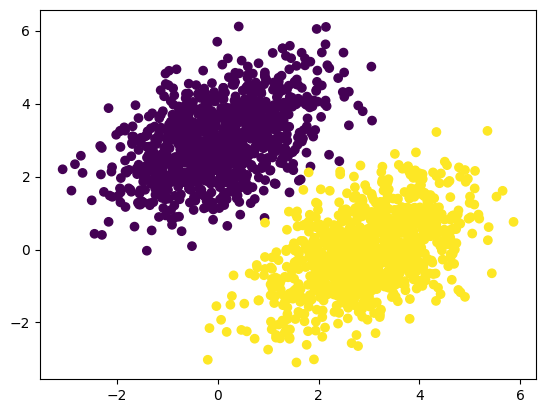

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0])
plt.show()

Now, let’s create a linear classifier that can learn to separate these two blobs. A linear
classifier is an affine transformation (`prediction = matmul(input, W) + b`) trained to
minimize the square of the difference between predictions and the targets.
As you’ll see, it’s actually a much simpler example than the end-to-end example of a
toy two-layer neural network from the end of chapter 2. However, this time, you should
be able to understand everything about the code, line by line.
Let’s create our variables `W` and `b`, initialized with random values and with zeros,
respectively.

In [52]:
input_dim = 2  # The inputs will be the 2D points

# The output predictions will be a single score per sample (close to 0 if the sample is
# predicted to be in class 0, and close to 1 if the sample is predicted to be in class 1)
output_dim = 1
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim)))


Here's our forward pass function.

In [53]:
def model(inputs, W, b):
    return tf.matmul(inputs, W) + b

Because our linear classifier operates on 2D inputs, `W` is really just two scalar coefficients:
`W = [[w1], [w2]]`. Meanwhile, `b`is a single scalar coefficient. As such, for given
input point `[x, y]`, its prediction value is `prediction = [[w1], [w2]] • [x, y] + b = w1 * x + w2 * y + b`.

Here’s our loss function.

In [ ]:
def mean_squared_error(targets, predictions):

    # per_sample_losses will be a tensor with the same shape as targets and predictions, containing per-sample loss scores
    per_sample_losses = tf.square(targets - predictions)

    # we need to average these per-sample loss scores into a single scalar loss value: reduce_mean does this
    return tf.reduce_mean(per_sample_losses)

Now, we move to the training step, which receives some training data and updates the weights `W` and `b` to minimize the loss on the data.

In [ ]:
learning_rate = 0.1


@tf.function(
    jit_compile=True
)  # Wraps the function in a tf.function decorator to speed it up
def training_step(inputs, targets, W, b):
    with tf.GradientTape() as tape:
        predictions = model(inputs, W, b)
        loss = mean_squared_error(
            predictions, targets
        )  # Forward pass, inside of a gradient tape scope
    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(
        loss, [W, b]
    )  # Retrieves the gradient of the loss with regard to weights

    # update the weights
    W.assign_sub(grad_loss_wrt_W * learning_rate)
    b.assign_sub(grad_loss_wrt_b * learning_rate)
    return loss


For simplicity, we’ll do `batch training `instead of `mini-batch training`: we’ll run each training
step (gradient computation and weight update) on the entire data, rather than
iterate over the data in small batches. On one hand, this means that each training step
will take much longer to run, since we compute the forward pass and the gradients for
2,000 samples at once. On the other hand, each gradient update will be much more
effective at reducing the loss on the training data, since it will encompass information
from all training samples instead of, say, only 128 random samples. As a result, we will
need many fewer steps of training, and we should use a larger learning rate than what
we would typically use for mini-batch training (we’ll use `learning_rate = 0.1`, as previously
defined).

In [60]:
for step in range(40):
    loss = training_step(inputs, targets, W, b)
    print(f"Loss at step {step}: {loss:.4f}")

Loss at step 0: 0.0295
Loss at step 1: 0.0291
Loss at step 2: 0.0289
Loss at step 3: 0.0286
Loss at step 4: 0.0283
Loss at step 5: 0.0281
Loss at step 6: 0.0279
Loss at step 7: 0.0277
Loss at step 8: 0.0276
Loss at step 9: 0.0274
Loss at step 10: 0.0273
Loss at step 11: 0.0271
Loss at step 12: 0.0270
Loss at step 13: 0.0269
Loss at step 14: 0.0268
Loss at step 15: 0.0267
Loss at step 16: 0.0266
Loss at step 17: 0.0266
Loss at step 18: 0.0265
Loss at step 19: 0.0264
Loss at step 20: 0.0264
Loss at step 21: 0.0263
Loss at step 22: 0.0263
Loss at step 23: 0.0262
Loss at step 24: 0.0262
Loss at step 25: 0.0262
Loss at step 26: 0.0261
Loss at step 27: 0.0261
Loss at step 28: 0.0261
Loss at step 29: 0.0260
Loss at step 30: 0.0260
Loss at step 31: 0.0260
Loss at step 32: 0.0260
Loss at step 33: 0.0260
Loss at step 34: 0.0259
Loss at step 35: 0.0259
Loss at step 36: 0.0259
Loss at step 37: 0.0259
Loss at step 38: 0.0259
Loss at step 39: 0.0259


After 40 steps, the training loss seems to have stabilized around 0.025. Let’s plot how
our linear model classifies the training data points, as shown in figure 3.2. Because our
targets are 0s and 1s a given input point will be classified as “0” if its prediction value is
below 0.5, and as “1” if it is above 0.5:

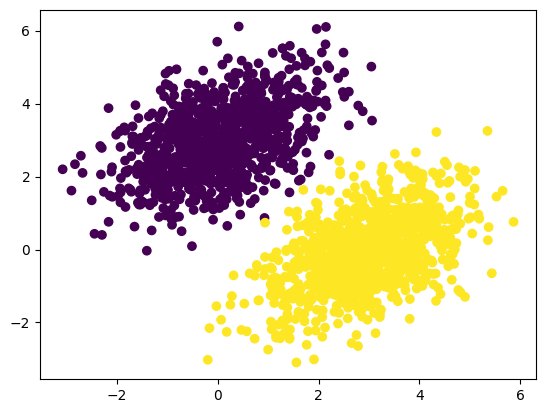

In [ ]:
predictions = model(inputs, W, b)
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()

Recall that the prediction value for a given point `[x, y]` is simply `prediction == [[w1],[w2]] • [x, y] + b == w1 * x + w2 * y + b`. 
Thus, class “0” is defined as `w1 * x + w2 * y + b < 0.5` and class “1” is defined as `w1 * x + w2 * y + b > 0.5`. You’ll notice that what
you’re looking at is really the equation of a line in the 2D plane: `w1 * x + w2 * y + b = 0.5`. Class 1 is above the line; class 0 is below the line. You may be used to seeing line
equations in the format `y = a * x + b`; in the same format, our line becomes `y = - w1 / w2 * x + (0.5 - b) / w2`.

Let’s plot this line, as shown in figure 3.3:

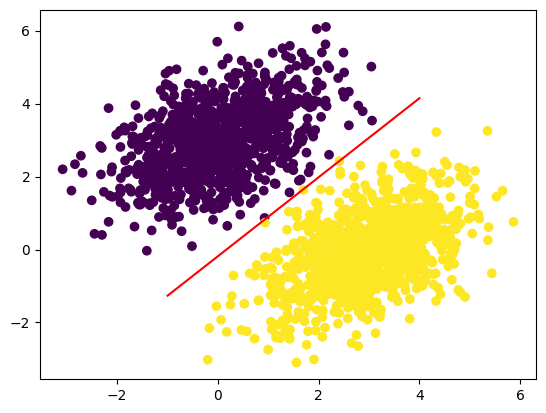

In [ ]:
# Generates 100 regularly spaced numbers between - 1 and 4, which we will use to plot our line
x = np.linspace(-1, 4, 100)
y = -W[0] / W[1] * x + (0.5 - b) / W[1]  # this is our line's equation
plt.plot(x, y, "-r")  # Plots our line ("-r" means "plot it as a red line")
# plots our model's predictions on the same plot
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()


This is really what a linear classifier is all about: finding the parameters of a line (or, in higher-dimensional spaces, a hyperplane) neatly separating two classes of data.